## **Bradford Winter Air Quality Analysis**

**Period:** 1 Nov 2024 – 17 Jan 2025  
**Pollutants:** PM2.5 and PM10  

**Sites:**  
- Bradford Keighley  
- Bradford Tong Street  
- Bradford Treadwell Mills  

**Author:** Folasayo Ogundipe

### **Configuration**

#### **Install required packages:** 

   This ensures the Python environment has the exact libraries needed to run the analysis.

In [19]:
# Install required packages

#import sys
pip install -r ../requirements.txt

zsh:1: command not found: pip


#### **Import necessary libraries:**
This loads the tools needed for:
- file handling + patterns (os, re)
- numeric processing (numpy)
- tabular data analysis (pandas)
- data visualisation (matplotlib & plotly)
- path creation (Path)

In [2]:
# Import the necessary libraries

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

import warnings

#### **Path allocation:**
This defines standard folders used in the project for:
- raw input data (`data/raw`)
- processed data (`data/processed`
- external data (`data/external`)
- output directory (`outputs`)

In [3]:
# Create directory structure if it does not already exist
raw_data = Path("../data/raw")
pro_data = Path("../data/processed")
ext_data = Path("../data/external")
out_dir = Path("../outputs")

for path in [raw_data, pro_data, ext_data, out_dir]:
    path.mkdir(parents=True, exist_ok=True)

### **Data preprocessing**

#### **Load and structure data:**
- It loads the data and applies clear column names to enable reliable processing.
- Also fix the 24:00 o'clock to the next day 00:00 o'clock.
- Drop the invalid rows - especially the summary statistics at the base of the sheet

In [4]:
# Load and clean raw air quality data
input_file = raw_data / "Multi Station Report 01_11_2024.xlsx"
raw = pd.read_excel(input_file)

# Retain only required columns (A–G) based on data inspection
raw = raw.iloc[:, :7].copy()

# Rename columns to a stable, explicit schema
raw.columns = [
    "datetime",
    "keighley_pm10", "keighley_pm25",
    "tong_pm10",     "tong_pm25",
    "treadwell_pm10","treadwell_pm25"
]

warnings.filterwarnings(
    "ignore",
    message="Could not infer format",
    category=UserWarning
)

# Datetime cleaning
# Some rows contain 24:00, which pandas cannot parse directly.
# We convert 24:00 → 00:00 and add one day to preserve correctness.
dt_raw = raw["datetime"].astype(str).str.strip()
mask_24 = dt_raw.str.contains(r"\b24:00\b", na=False)

dt_fixed = dt_raw.copy()
dt_fixed.loc[mask_24] = dt_fixed.loc[mask_24].str.replace("24:00", "00:00", regex=False)

# Parse datetime (UK day-first format)
dt_parsed = pd.to_datetime(
    dt_fixed,
    errors="coerce",
    dayfirst=True
)

# Add one day where 24:00 was originally present
dt_parsed.loc[mask_24] = dt_parsed.loc[mask_24] + pd.Timedelta(days=1)

raw["datetime"] = dt_parsed

# Drop non-data rows (e.g. summary statistics at the bottom of the sheet)
raw = raw.dropna(subset=["datetime"]).reset_index(drop=True)

# Numeric coercion
# Convert pollution measurements to numeric
for c in raw.columns[1:]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

# Quick check
display(raw.head())
print("Shape:", raw.shape)

,datetime,keighley_pm10,keighley_pm25,tong_pm10,tong_pm25,treadwell_pm10,treadwell_pm25
0,2024-11-01 01:00:00,6.2,5.2,10.2,5.8,NaN,NaN
1,2024-11-01 02:00:00,1.0,-0.9,2.1,-1.3,NaN,NaN
2,2024-11-01 03:00:00,6.1,4.6,7.3,4.3,NaN,NaN
3,2024-11-01 04:00:00,5.8,4.2,11.6,7.8,NaN,NaN
4,2024-11-01 05:00:00,2.8,1.0,2.4,-1.4,NaN,NaN


Shape: (1848, 7)


#### **Reshape to tidy format:**
The data is reshaped into a tidy format with one row per site per timestamp (`datetime | site | pm10 | pm25`) to support analysis and comparison.

In [5]:
# Reshape to tidy (long) format
# Output schema: datetime | date | hour | week | site | pm10 | pm25
site_map = {
    "Keighley": ("keighley_pm10", "keighley_pm25"),
    "Tong Street": ("tong_pm10", "tong_pm25"),
    "Treadwell Mills": ("treadwell_pm10", "treadwell_pm25"),
}

frames = []
for site, (pm10_col, pm25_col) in site_map.items():
    tmp = raw[["datetime", pm10_col, pm25_col]].copy()
    tmp = tmp.rename(columns={pm10_col: "pm10", pm25_col: "pm25"})
    tmp["site"] = site
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)

# Time features derived strictly from datetime
df["date"] = df["datetime"].dt.normalize()                   # day (00:00 timestamp)
df["hour"] = df["datetime"].dt.hour
df["week"] = df["datetime"].dt.to_period("W-MON").astype(str) # week label (Mon–Sun)

# Final tidy ordering
df = df[["datetime", "date", "hour", "week", "site", "pm10", "pm25"]]
df = df.sort_values(["site", "datetime"]).reset_index(drop=True)

display(df.head())
print("Sites:", df["site"].unique())
print("Datetime range:", df["datetime"].min(), "to", df["datetime"].max())
print("Rows:", len(df))

,datetime,date,hour,week,site,pm10,pm25
0,2024-11-01 01:00:00,2024-11-01,1,2024-10-29/2024-11-04,Keighley,6.2,5.2
1,2024-11-01 02:00:00,2024-11-01,2,2024-10-29/2024-11-04,Keighley,1.0,-0.9
2,2024-11-01 03:00:00,2024-11-01,3,2024-10-29/2024-11-04,Keighley,6.1,4.6
3,2024-11-01 04:00:00,2024-11-01,4,2024-10-29/2024-11-04,Keighley,5.8,4.2
4,2024-11-01 05:00:00,2024-11-01,5,2024-10-29/2024-11-04,Keighley,2.8,1.0


Sites: ['Keighley' 'Tong Street' 'Treadwell Mills']
Datetime range: 2024-11-01 01:00:00 to 2025-01-17 00:00:00
Rows: 5544


### **Quality assurance checks**

#### **Commissioning window and reporting hours:**
- Commissioning windows were identified per site and pollutant using the first and last non-missing observations.
- Only data within these periods were treated as valid reporting time, allowing accurate calculation of reporting hours, downtime, and uptime.

In [6]:
# Commissioned window per site & pollutant
# Based on non-missing measurements

def commissioning_by_pollutant(df: pd.DataFrame, pollutant: str, label: str) -> pd.DataFrame:
    out = (
        df.dropna(subset=[pollutant])
          .groupby("site", as_index=False)
          .agg(
              commissioned_from=("datetime", "min"),
              commissioned_to=("datetime", "max"),
              observed_hours=("datetime", "count"),
          )
    )

    # Expected hours in the commissioned window (inclusive)
    out["expected_hours"] = (
        (out["commissioned_to"] - out["commissioned_from"]) / pd.Timedelta(hours=1)
    ).round().astype(int) + 1

    out["downtime_hours"] = out["expected_hours"] - out["observed_hours"]
    out["uptime_pct"] = (out["observed_hours"] / out["expected_hours"] * 100).round(2)

    out["pollutant"] = label
    return out
    

commissioning_pm10 = commissioning_by_pollutant(df, pollutant="pm10", label="PM10")
commissioning_pm25 = commissioning_by_pollutant(df, pollutant="pm25", label="PM2.5")

commissioning = (
    pd.concat([commissioning_pm10, commissioning_pm25], ignore_index=True)
      .loc[:, ["site", "pollutant", "commissioned_from", "commissioned_to",
               "expected_hours", "observed_hours", "downtime_hours", "uptime_pct"]]
      .sort_values(["site", "pollutant"])
      .reset_index(drop=True)
)

display(commissioning)

,site,pollutant,commissioned_from,commissioned_to,expected_hours,observed_hours,downtime_hours,uptime_pct
0,Keighley,PM10,2024-11-01 01:00:00,2025-01-17 00:00:00,1848,1793,55,97.02
1,Keighley,PM2.5,2024-11-01 01:00:00,2025-01-17 00:00:00,1848,1802,46,97.51
2,Tong Street,PM10,2024-11-01 01:00:00,2025-01-03 10:00:00,1522,1466,56,96.32
3,Tong Street,PM2.5,2024-11-01 01:00:00,2025-01-03 10:00:00,1522,1438,84,94.48
4,Treadwell Mills,PM10,2024-12-21 01:00:00,2025-01-17 00:00:00,648,648,0,100.00
5,Treadwell Mills,PM2.5,2024-12-21 01:00:00,2025-01-17 00:00:00,648,648,0,100.00


#### **Extreme values quality assurance:** 
- Extreme values were examined to identify potential outliers or implausible readings before any data cleaning was applied.
- This highlights unusually high or low values, including negative concentrations, which indicate potential sensor or data recording issues.

In [7]:
# Extreme values QA (RAW data)
# Purpose: surface outliers / impossible values (e.g., negatives)

POLLUTANT_LABELS = {"pm10": "PM10", "pm25": "PM2.5"}

def extremes_by_pollutant(df: pd.DataFrame, pol: str) -> pd.DataFrame:
    d = df.dropna(subset=[pol]).loc[:, ["site", "datetime", pol]]

    max_df = (
        d.sort_values(pol, ascending=False)
         .groupby("site", as_index=False)
         .first()
         .rename(columns={pol: "max_value", "datetime": "max_datetime"})
    )

    min_df = (
        d.sort_values(pol, ascending=True)
         .groupby("site", as_index=False)
         .first()
         .rename(columns={pol: "min_value", "datetime": "min_datetime"})
    )

    out = (
        max_df.merge(min_df, on="site", how="inner")
              .assign(pollutant=POLLUTANT_LABELS[pol])
              .loc[:, ["site", "pollutant", "max_datetime", "max_value", "min_datetime", "min_value"]]
              .sort_values(["site", "pollutant"])
              .reset_index(drop=True)
    )
    return out

extremes_raw = (
    pd.concat(
        [extremes_by_pollutant(df, "pm10"),
         extremes_by_pollutant(df, "pm25")],
        ignore_index=True
    )
    .sort_values(["site", "pollutant"])
    .reset_index(drop=True)
)

display(extremes_raw)

,site,pollutant,max_datetime,max_value,min_datetime,min_value
0,Keighley,PM10,2025-01-16 21:00:00,261.0,2025-01-05 16:00:00,-4.0
1,Keighley,PM2.5,2024-11-06 00:00:00,97.5,2025-01-05 16:00:00,-3.9
2,Tong Street,PM10,2024-12-17 15:00:00,204.0,2024-12-08 12:00:00,-3.3
3,Tong Street,PM2.5,2024-12-17 15:00:00,164.3,2024-12-07 12:00:00,-4.7
4,Treadwell Mills,PM10,2025-01-16 19:00:00,329.2,2024-12-25 07:00:00,0.3
5,Treadwell Mills,PM2.5,2025-01-16 19:00:00,65.7,2025-01-05 09:00:00,0.3


#### **Negative values assessment:** 
- Negative PM2.5 and PM10 readings were quantified to understand the scale of invalid measurements.
- For each site and pollutant, the number and percentage of negative values were calculated using only observed (non-missing) data.

In [8]:
# Negative values summary (RAW)
# Purpose: quantify how common invalid readings are

def negative_values_summary(df: pd.DataFrame, pol: str) -> pd.DataFrame:
    tmp = df.loc[:, ["site", pol]].dropna(subset=[pol]).copy()
    tmp["is_negative"] = tmp[pol] < 0

    out = (
        tmp.groupby("site", as_index=False)
           .agg(
               observed_count=(pol, "count"),
               negative_count=("is_negative", "sum"),
               negative_pct=("is_negative", "mean"),
           )
    )
    out["negative_pct"] = (out["negative_pct"] * 100).round(2)
    out["pollutant"] = POLLUTANT_LABELS[pol]
    return out

negative_summary = (
    pd.concat(
        [negative_values_summary(df, "pm10"),
         negative_values_summary(df, "pm25")],
        ignore_index=True
    )
    .loc[:, ["site", "pollutant", "observed_count", "negative_count", "negative_pct"]]
    .sort_values(["site", "pollutant"])
    .reset_index(drop=True)
)

display(negative_summary)

,site,pollutant,observed_count,negative_count,negative_pct
0,Keighley,PM10,1793,30,1.67
1,Keighley,PM2.5,1802,81,4.50
2,Tong Street,PM10,1466,41,2.80
3,Tong Street,PM2.5,1438,170,11.82
4,Treadwell Mills,PM10,648,0,0.00
5,Treadwell Mills,PM2.5,648,0,0.00


#### **Treatment of invalid values:**
- Negative PM values were treated as invalid and set to missing.
- Extreme values were then re-evaluated using the cleaned dataset to confirm that implausible minima had been removed and that the data were suitable for further analysis.

In [9]:
# Treat negative PM values as invalid + re-check extremes

df_clean = df.copy()
df_clean.loc[df_clean["pm10"] < 0, "pm10"] = np.nan
df_clean.loc[df_clean["pm25"] < 0, "pm25"] = np.nan

extremes_clean = (
    pd.concat(
        [extremes_by_pollutant(df_clean, "pm10"),
         extremes_by_pollutant(df_clean, "pm25")],
        ignore_index=True
    )
    .sort_values(["site", "pollutant"])
    .reset_index(drop=True)
)

display(extremes_clean)

,site,pollutant,max_datetime,max_value,min_datetime,min_value
0,Keighley,PM10,2025-01-16 21:00:00,261.0,2025-01-05 10:00:00,0.0
1,Keighley,PM2.5,2024-11-06 00:00:00,97.5,2025-01-06 09:00:00,0.0
2,Tong Street,PM10,2024-12-17 15:00:00,204.0,2024-12-07 23:00:00,0.0
3,Tong Street,PM2.5,2024-12-17 15:00:00,164.3,2024-12-08 04:00:00,0.0
4,Treadwell Mills,PM10,2025-01-16 19:00:00,329.2,2024-12-25 07:00:00,0.3
5,Treadwell Mills,PM2.5,2025-01-16 19:00:00,65.7,2024-12-25 07:00:00,0.3


### **Save the final QA tables:**
- Following quality assurance and data cleaning, key outputs were saved to support reproducibility and transparency.

In [10]:
# Save processed data for reproducibility
# Clean hourly dataset used for all analysis
df_clean.to_csv(
    pro_data / "air_quality_hourly_clean.csv",
    index=False
)

# Sensor commissioning, uptime and downtime summary
commissioning.to_csv(
    pro_data / "qa_commissioning_uptime_by_site_pollutant.csv",
    index=False
)

# Summary of invalid (negative) values used to justify cleaning
negative_summary.to_csv(
    pro_data / "qa_negative_values_summary.csv",
    index=False
)

print(f"Processed data saved to: {pro_data.resolve()}")

Processed data saved to: /Users/sayo2rule/Documents/Projects/bradford-air-quality-hdrc/data/processed


## **Analysis and insights**

### **Daily aggregation of PM2.5 and PM10:**
- Hourly measurements were aggregated to daily means to support interpretation by Elected Members.
- Aggregation was performed per site and pollutant, using only valid observations.
- This reduces short-term noise and highlights clearer winter trends and site comparisons.

In [11]:
# Daily aggregation

daily = (
    df_clean
    .groupby(["site", "date"], as_index=False)
    .agg(
        pm10_mean=("pm10", "mean"),
        pm25_mean=("pm25", "mean"),
        pm10_obs=("pm10", "count"),
        pm25_obs=("pm25", "count"),
    )
)

# Round up
daily[["pm10_mean", "pm25_mean"]] = daily[["pm10_mean", "pm25_mean"]].round(2)

display(daily.head())
print("Daily records:", daily.shape)

,site,date,pm10_mean,pm25_mean,pm10_obs,pm25_obs
0,Keighley,2024-11-01,11.30,8.55,23,22
1,Keighley,2024-11-02,14.77,12.72,24,24
2,Keighley,2024-11-03,17.97,15.31,24,24
3,Keighley,2024-11-04,24.30,17.63,24,24
4,Keighley,2024-11-05,34.62,30.92,24,24


Daily records: (234, 6)


### **Daily exceedance analysis:**
- Daily mean PM2.5 and PM10 were compared against WHO guideline reference values.
- Exceedance days indicate periods of elevated pollution, not regulatory breaches.
- Summaries by site show how often air quality was a concern during winter.

In [12]:
# -----------------------------
# Contextual daily exceedance (COMMISSIONING-BASED DENOMINATOR)
# Separate outputs for PM2.5 and PM10
# -----------------------------

WHO_PM25_DAILY = 15.0
WHO_PM10_DAILY = 45.0

# Ensure date is normalised (midnight)
daily2 = daily.copy()
daily2["date"] = pd.to_datetime(daily2["date"]).dt.normalize()

# Prepare commissioning window as dates
comm = commissioning.copy()
comm["comm_from_date"] = pd.to_datetime(comm["commissioned_from"]).dt.normalize()
comm["comm_to_date"]   = pd.to_datetime(comm["commissioned_to"]).dt.normalize()
comm["expected_days"]  = (comm["comm_to_date"] - comm["comm_from_date"]).dt.days + 1

def exceedance_table(pol_label: str, mean_col: str, threshold: float) -> pd.DataFrame:
    """Commissioning-based exceedance table for one pollutant."""
    comm_pol = (
        comm.loc[comm["pollutant"] == pol_label, ["site", "comm_from_date", "comm_to_date", "expected_days"]]
            .rename(columns={"expected_days": "days_commissioned"})
            .copy()
    )

    tmp = daily2.merge(comm_pol, on="site", how="left")

    in_window = tmp["date"].between(tmp["comm_from_date"], tmp["comm_to_date"])
    tmp["exceed"] = (tmp[mean_col] > threshold) & in_window

    out = (
        tmp.loc[in_window]
           .groupby("site", as_index=False)
           .agg(
               days_commissioned=("days_commissioned", "first"),
               exceed_days=("exceed", "sum"),
           )
    )
    out["exceed_pct"] = (out["exceed_days"] / out["days_commissioned"] * 100).round(1)
    out.insert(1, "pollutant", pol_label)
    return out.sort_values("site").reset_index(drop=True)

# Separate tables
exceed_pm25 = exceedance_table("PM2.5", "pm25_mean", WHO_PM25_DAILY)
exceed_pm10 = exceedance_table("PM10",  "pm10_mean", WHO_PM10_DAILY)

display(exceed_pm25)
display(exceed_pm10)

,site,pollutant,days_commissioned,exceed_days,exceed_pct
0,Keighley,PM2.5,78,13,16.7
1,Tong Street,PM2.5,64,7,10.9
2,Treadwell Mills,PM2.5,28,5,17.9


,site,pollutant,days_commissioned,exceed_days,exceed_pct
0,Keighley,PM10,78,1,1.3
1,Tong Street,PM10,64,0,0.0
2,Treadwell Mills,PM10,28,2,7.1


#### **Interpretation: Daily exceedance of PM2.5 and PM10**

- PM2.5 exceedances were observed more frequently than PM10 across all sites during the winter period.
- Keighley recorded the highest proportion of PM2.5 exceedance days (16.7%), suggesting greater winter exposure at this location.
- PM10 exceedances were rare across all sites, occurring on fewer than 3% of observed days.
- This indicates that fine particulate pollution (PM2.5) represents the more persistent air-quality concern during winter.

### **Overall daily air quality trends**
To provide a station-wide view of air quality over the winter period, daily mean PM2.5 and PM10 concentrations were averaged across all monitoring sites.

- Hourly measurements were first aggregated to daily means at each site.
- Daily means were then averaged across sites to show overall trends.
- This view highlights broader temporal patterns and helps identify periods of elevated pollution affecting the district as a whole.

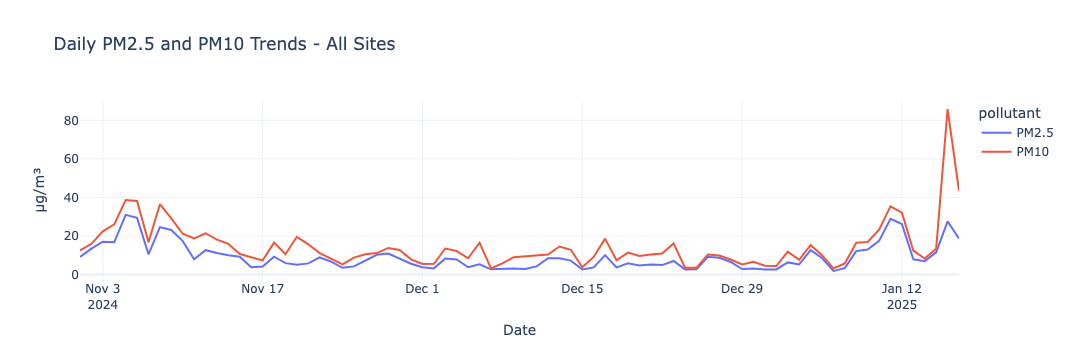

In [13]:
# Daily mean across all the sites
overall_daily = (
    daily.groupby("date", as_index=False)
         .agg(
             pm25_mean=("pm25_mean", "mean"),
             pm10_mean=("pm10_mean", "mean")
         )
)

# Reshape to long format
overall_long = overall_daily.melt(
    id_vars="date",
    value_vars=["pm25_mean", "pm10_mean"],
    var_name="pollutant",
    value_name="value"
)

overall_long["pollutant"] = overall_long["pollutant"].map({
    "pm25_mean": "PM2.5",
    "pm10_mean": "PM10"
})

fig_overall = px.line(
    overall_long,
    x="date",
    y="value",
    color="pollutant",
    title="Daily PM2.5 and PM10 Trends - All Sites",
    labels={"value": "µg/m³", "date": "Date"},
)

fig_overall.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

fig_overall.show()

# Save interactive version
pio.write_html(fig_overall, out_dir / "trend_overall_daily.html", include_plotlyjs="cdn")

#### **Interpretation: Overall daily air quality trends**

- PM2.5 and PM10 follow similar patterns over the winter period, suggesting shared pollution drivers such as traffic, domestic heating, and weather conditions.
- Higher concentrations are observed in early November and again in mid-January, consistent with colder conditions and reduced atmospheric dispersion.
- Pollution levels are generally lower and more stable through December, indicating fewer accumulation events.
- The sharp spike in mid-January suggests a short-term pollution episode, likely driven by weather conditions rather than long-term trends.


### **Daily PM10 trends by site**

Daily mean PM10 concentrations were plotted for each monitoring site to compare temporal patterns across locations.

- This view highlights similarities and differences in PM10 behaviour between sites over the winter period.
- A WHO 24-hour PM10 guideline (45 µg/m³) is shown as a reference line to help contextualise higher pollution episodes.
- The guideline is used for **interpretation only** and does not represent a regulatory limit.

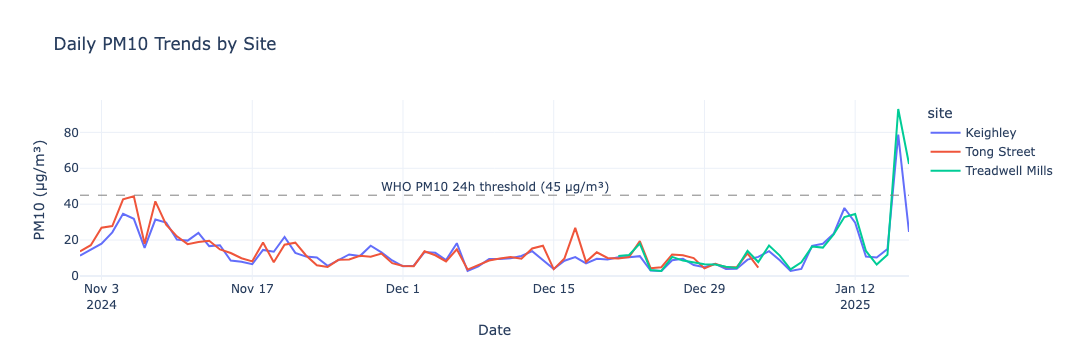

In [14]:
WHO_PM10_24H = 45  # µg/m³ (WHO 2021 guideline)

pm10_site = daily[["site", "date", "pm10_mean"]].copy()
pm10_site["date"] = pd.to_datetime(pm10_site["date"])

fig_pm10 = px.line(
    pm10_site,
    x="date",
    y="pm10_mean",
    color="site",
    title="Daily PM10 Trends by Site",
    labels={"pm10_mean": "PM10 (µg/m³)", "date": "Date"},
)

fig_pm10.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

# Add WHO guideline reference line
fig_pm10.add_hline(
    y=WHO_PM10_24H,
    line_dash="dash",
    line_color="grey",
    line_width=1,
    annotation_text="WHO PM10 24h threshold (45 µg/m³)",
    annotation_position="top"
)

fig_pm10.show()

# Save interactive version
pio.write_html(
    fig_pm10,
    out_dir / "trend_pm10_by_site.html",
    include_plotlyjs="cdn"
)

#### **Interpretation: Daily PM10 trends by site**
- PM10 levels follow similar patterns across all sites, indicating shared influences such as traffic, heating and weather conditions.
- For most of the winter period, daily PM10 concentrations remain well below the WHO 24-hour reference level.
- Short-lived spikes occur at all sites in mid-January, with Treadwell Mills showing the highest peak, followed by Keighley, suggesting a localised pollution episode.


### **Daily PM2.5 trends by site**

Daily mean PM2.5 concentrations were plotted for each monitoring site to examine variation across locations over the winter period.

- PM2.5 levels show similar temporal patterns across sites, with differences most visible during peak pollution episodes.
- A WHO 24-hour PM2.5 guideline (15 µg/m³) is shown as a reference to help contextualise higher concentration days.
- The guideline is used for **public health interpretation only** and does not represent a regulatory limit.

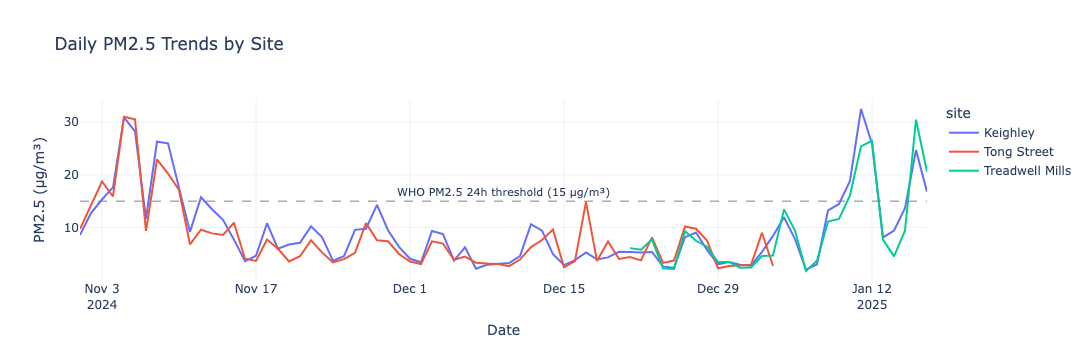

In [15]:
WHO_PM25_24H = 15  # µg/m³ (WHO 2021 guideline)

pm25_site = daily[["site", "date", "pm25_mean"]].copy()
pm25_site["date"] = pd.to_datetime(pm25_site["date"])

fig_pm25 = px.line(
    pm25_site,
    x="date",
    y="pm25_mean",
    color="site",
    title="Daily PM2.5 Trends by Site",
    labels={"pm25_mean": "PM2.5 (µg/m³)", "date": "Date"},
)

fig_pm25.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

# Add WHO guideline reference line
fig_pm25.add_hline(
    y=WHO_PM25_24H,
    line_dash="dash",
    line_color="grey",
    line_width=1,
    annotation_text="WHO PM2.5 24h threshold (15 µg/m³)",
    annotation_position="top",
    annotation_font_size=11
)

fig_pm25.show()

# Save interactive version
pio.write_html(
    fig_pm25,
    out_dir / "trend_pm25_by_site.html",
    include_plotlyjs="cdn"
)

#### **Interpretation – Daily PM2.5 trends by site**
- PM2.5 levels show greater variability than PM10, with sharper peaks across all sites.
- Several days exceed the WHO 24-hour reference level, particularly in early November and mid-January.
- Keighley and Treadwell Mills experience the highest peak PM2.5 concentrations, while Tong Street is generally lower.
- These short-lived spikes suggest weather-driven pollution episodes, such as cold, stagnant conditions, rather than sustained high pollution.

### Site Ranking by Average Daily Pollution

To compare air quality across locations, sites were ranked using the average of daily mean concentrations over the winter period.
- Rankings were produced separately for PM2.5 and PM10.
- Daily means were averaged using only days with valid data for each site.
- This emphasises consistent pollution levels rather than short-lived peaks.
- The number of observed days is shown alongside rankings to provide context on data coverage.

In [16]:
# Site ranking tables (separate PM2.5 vs PM10) + quick sanity checks

# Build ranking base with correct "days with data" per pollutant
site_ranking = (
    daily.groupby("site", as_index=False)
         .agg(
             pm25_avg_daily=("pm25_mean", "mean"),
             pm10_avg_daily=("pm10_mean", "mean"),
             pm25_days_with_data=("pm25_mean", lambda s: int(s.notna().sum())),
             pm10_days_with_data=("pm10_mean", lambda s: int(s.notna().sum())),
         )
)

site_ranking[["pm25_avg_daily", "pm10_avg_daily"]] = site_ranking[["pm25_avg_daily", "pm10_avg_daily"]].round(2)

# Create truly separate tables (so they won't look identical)
rank_pm25 = (
    site_ranking[["site", "pm25_avg_daily", "pm25_days_with_data"]]
    .sort_values("pm25_avg_daily", ascending=False)
    .reset_index(drop=True)
)

rank_pm10 = (
    site_ranking[["site", "pm10_avg_daily", "pm10_days_with_data"]]
    .sort_values("pm10_avg_daily", ascending=False)
    .reset_index(drop=True)
)

display(rank_pm25)
display(rank_pm10)

,site,pm25_avg_daily,pm25_days_with_data
0,Keighley,9.50,78
1,Treadwell Mills,9.27,28
2,Tong Street,7.77,64


,site,pm10_avg_daily,pm10_days_with_data
0,Treadwell Mills,16.69,28
1,Keighley,13.74,78
2,Tong Street,13.44,64


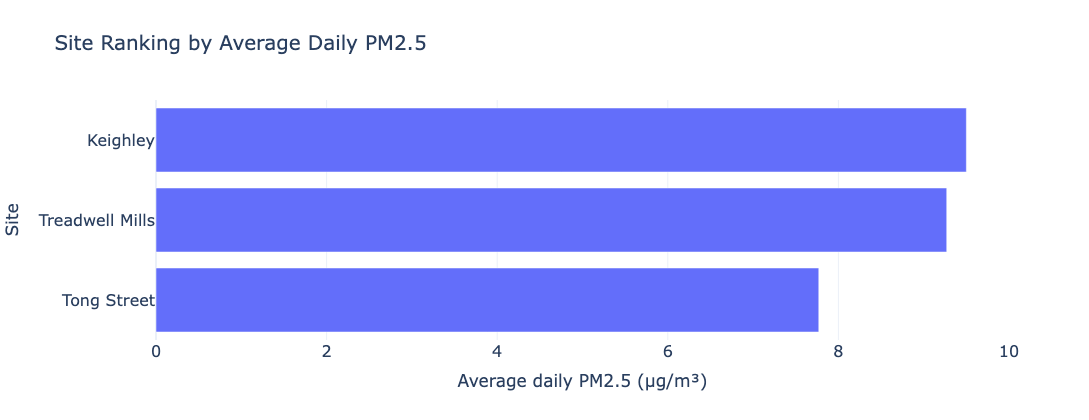

In [17]:
fig_rank_pm25 = px.bar(
    rank_pm25,
    x="pm25_avg_daily",
    y="site",
    orientation="h",
    title="Site Ranking by Average Daily PM2.5",
    labels={
        "pm25_avg_daily": "Average daily PM2.5 (µg/m³)",
        "site": "Site"
    },
    hover_data={"pm25_days_with_data": True},
)

fig_rank_pm25.update_layout(
    template="plotly_white",
    height=420,
    title_font_size=20
)

# Make axis ticks larger
fig_rank_pm25.update_xaxes(
    tickfont=dict(size=16),
    title_font=dict(size=17)
)

fig_rank_pm25.update_yaxes(
    categoryorder="total ascending",
    tickfont=dict(size=16),
    title_font=dict(size=17)
)

fig_rank_pm25.show()

pio.write_html(
    fig_rank_pm25,
    out_dir / "ranking_pm25_by_site.html",
    include_plotlyjs="cdn"
)

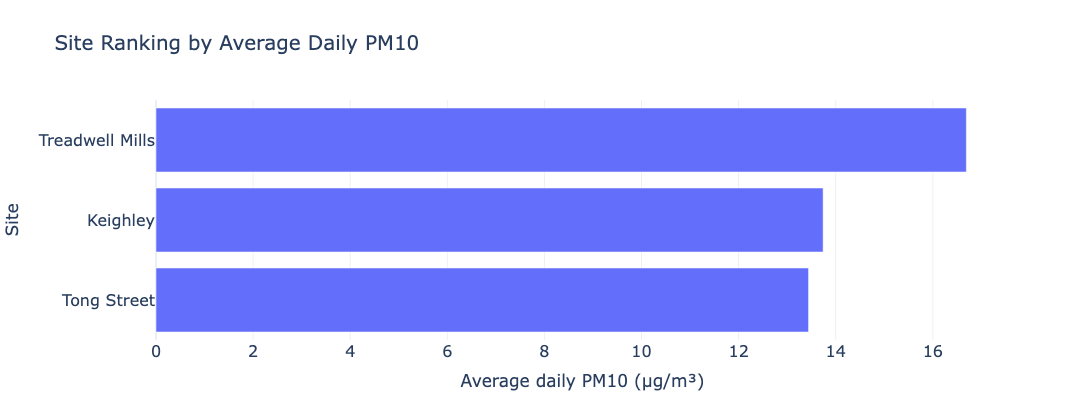

In [18]:
fig_rank_pm10 = px.bar(
    rank_pm10,
    x="pm10_avg_daily",
    y="site",
    orientation="h",
    title="Site Ranking by Average Daily PM10",
    labels={
        "pm10_avg_daily": "Average daily PM10 (µg/m³)",
        "site": "Site"
    },
    hover_data={"pm10_days_with_data": True},
)

fig_rank_pm10.update_layout(
    template="plotly_white",
    height=420,
    title_font_size=20
)

# Make axis ticks larger
fig_rank_pm10.update_xaxes(
    tickfont=dict(size=16),
    title_font=dict(size=17)
)

fig_rank_pm10.update_yaxes(
    categoryorder="total ascending",
    tickfont=dict(size=16),
    title_font=dict(size=17)
)

fig_rank_pm10.show()

pio.write_html(
    fig_rank_pm10,
    out_dir / "ranking_pm10_by_site.html",
    include_plotlyjs="cdn"
)

#### **Interpretation: Site ranking by average daily pollution**
- PM2.5: Keighley records the highest average daily PM2.5 over the winter period, followed by Treadwell Mills, with Tong Street showing the lowest average levels.
- PM10: Treadwell Mills has the highest average daily PM10, while Keighley and Tong Street show similar, slightly lower levels.
- These rankings reflect typical winter conditions at each site rather than short-term spikes, as they are based on averages across all observed days.
- Differences between sites suggest local influences such as traffic patterns, surrounding land use, and proximity to emission sources.
